In [20]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import  mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,LeakyReLU
from tensorflow.keras.optimizers import Adam

In [6]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [8]:
print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (60000, 28, 28)
Testing data shape: (10000, 28, 28)


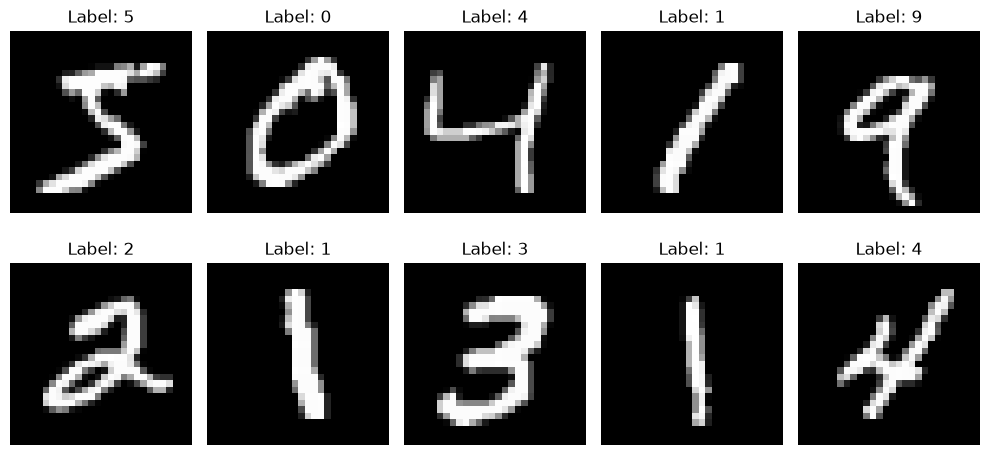

In [9]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")
plt.tight_layout()
plt.show()

Normalizing and reshaping

In [11]:
X_train = X_train.astype("float32")
X_train = (X_train - 127.5)/127.5
X_train = X_train.reshape(
    X_train.shape[0],
    784
)
print(X_train.shape)

(60000, 784)


In [14]:
generator = Sequential([
    Dense(256, input_dim=100),
    LeakyReLU(negative_slope=0.2),
    Dense(512),
    LeakyReLU(negative_slope=0.2),
    Dense(1024),
    LeakyReLU(negative_slope=0.2),
    Dense(784, activation="tanh")
])

c:\Apeetha\GAN_MNIST_Assignment\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [15]:
generator.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 256)            │        25,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 784)            │       803,600 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,486,352 (5.67 MB)

 Trainable params: 1,486,352 (5.67 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
generator.compile(
    loss='binary_crossentropy',
    optimizer = Adam(learning_rate=0.0002,
                     beta_1=0.5),
                     metrics=["accuracy"]
)

In [17]:
discriminator = Sequential([
    Dense(512, input_dim=784),
    LeakyReLU(negative_slope=0.2),
    Dense(256),
    LeakyReLU(negative_slope=0.2),
    Dense(1, activation="sigmoid")
])
discriminator.summary()

c:\Apeetha\GAN_MNIST_Assignment\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_6 (LeakyReLU)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_7 (LeakyReLU)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 533,505 (2.04 MB)

 Trainable params: 533,505 (2.04 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
discriminator.compile(
    loss="binary_crossentropy",
    optimizer=Adam(
        learning_rate=0.0002,
        beta_1=0.5
    ),
    metrics=["accuracy"]
)

In [19]:
discriminator.trainable = False
gan = Sequential([
    generator,
    discriminator
])

gan.compile(
    loss="binary_crossentropy",
    optimizer=Adam(
        learning_rate=0.0002,
        beta_1=0.5
    )
)
gan.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_1 (Sequential)       │ (None, 784)            │     1,486,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_2 (Sequential)       │ (None, 1)              │       533,505 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,019,857 (7.71 MB)

 Trainable params: 1,486,352 (5.67 MB)

 Non-trainable params: 533,505 (2.04 MB)

In [ ]:
epochs = 10000
batch_size = 64

d_losses = []
g_losses = []

for epoch in range(epochs):
  discriminator.trainable = True
  idx = np.random.randint(
        0,
        X_train.shape[0],
        batch_size
    )
  real_images = X_train[idx]
  noise = np.random.normal(0,1,
        (batch_size, 100)
        )

  fake_images = generator.predict(
        noise,
        verbose=0
    )
  real_labels = np.ones(
        (batch_size, 1)
    )

  fake_labels = np.zeros(
        (batch_size, 1)
    )
  d_loss_real = discriminator.train_on_batch(
        real_images,
        real_labels
    )
  d_loss_fake = discriminator.train_on_batch(
        fake_images,
        fake_labels
    )
  d_loss = (
        d_loss_real[0] +
        d_loss_fake[0]
    ) / 2
  
  ds=discriminator.trainable = False
  
  noise = np.random.normal(
        0,
        1,
        (batch_size, 100)
    )
  misleading_labels = np.ones(
        (batch_size, 1)
    )

  g_loss = gan.train_on_batch(
        noise,
        misleading_labels
    )

  d_losses.append(d_loss)
  g_losses.append(float(g_loss))

  if epoch % 1000 == 0:
        print(
            f"Epoch: {epoch} | "
            f"Discriminator Loss: {d_loss:.4f} | "
            f"Generator Loss: {float(g_loss):.4f}"
        )

Epoch: 0 | Discriminator Loss: 0.7466 | Generator Loss: 0.6962
Epoch: 1000 | Discriminator Loss: 0.5708 | Generator Loss: 1.3083
Epoch: 2000 | Discriminator Loss: 0.5093 | Generator Loss: 1.4313
Epoch: 3000 | Discriminator Loss: 0.4933 | Generator Loss: 1.2216
Epoch: 4000 | Discriminator Loss: 0.6427 | Generator Loss: 1.0559
Epoch: 5000 | Discriminator Loss: 0.6129 | Generator Loss: 1.1094
Epoch: 6000 | Discriminator Loss: 0.5782 | Generator Loss: 1.0115
Epoch: 7000 | Discriminator Loss: 0.5669 | Generator Loss: 0.9747
Epoch: 8000 | Discriminator Loss: 0.6432 | Generator Loss: 0.9958
Epoch: 9000 | Discriminator Loss: 0.6454 | Generator Loss: 0.9513


In [22]:
noise = np.random.normal(
    0,
    1,
    (10, 100)
)
generated_images = generator.predict(
    noise
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 479ms/step


In [23]:
generated_images = (
    generated_images * 127.5
) + 127.5
generated_images = generated_images.reshape(
    10,
    28,
    28
)

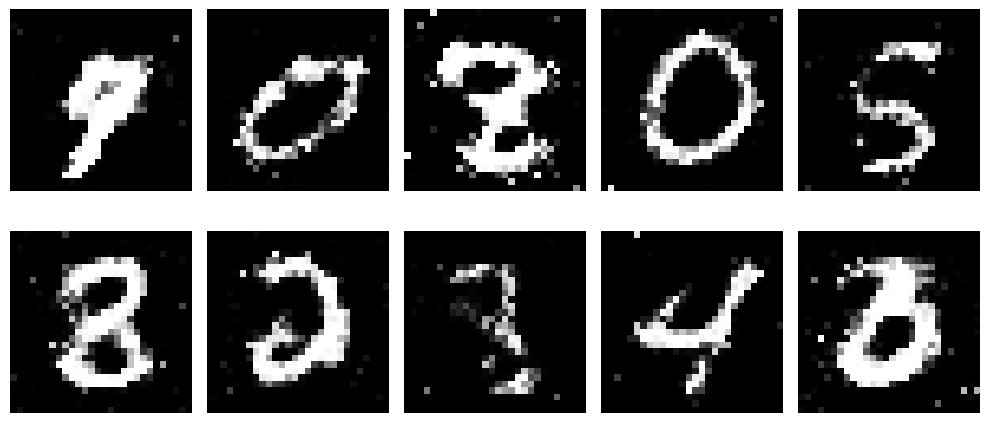

In [24]:
plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(
        generated_images[i],
        cmap="gray"
    )
    plt.axis("off")
plt.tight_layout()
plt.show()

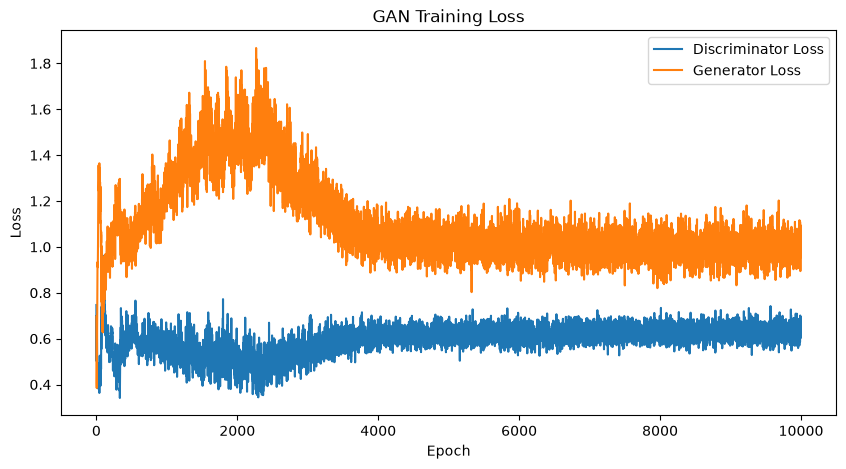

In [25]:
plt.figure(figsize=(10, 5))

plt.plot(
    d_losses,
    label="Discriminator Loss"
)
plt.plot(
    g_losses,
    label="Generator Loss"
)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("GAN Training Loss")
plt.legend()
plt.show()

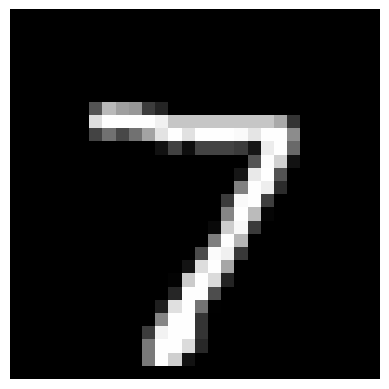

In [26]:
#checking with X_test image and generated fake image.

test_image = X_test[0]

plt.imshow(test_image, cmap="gray")
plt.axis("off")
plt.show()

In [28]:
test_image = test_image.astype("float32")
test_image = (test_image - 127.5)/127.5
test_image = test_image.reshape(1,784)

In [29]:
prediction = discriminator.predict(test_image, verbose=0)[0][0]

print("Discriminator score:", prediction)

if prediction >= 0.5:
    print("REAL")
else:
    print("FAKE")

Discriminator score: 0.43409947
FAKE


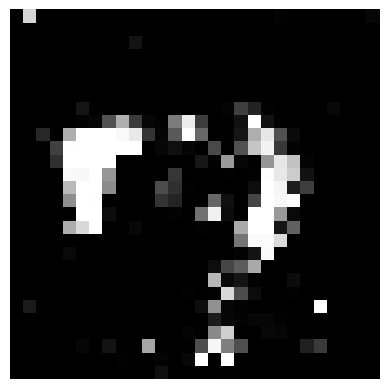

In [34]:
noise = np.random.normal(0, 1, (1, 100))

fake_image = generator.predict(noise, verbose=0)

fake_image_display = (
    fake_image[0] * 127.5
) + 127.5

fake_image_display = fake_image_display.reshape(28, 28)

plt.imshow(fake_image_display, cmap="gray")
plt.axis("off")
plt.show()



In [33]:
prediction = discriminator.predict(fake_image, verbose=0)[0][0]

print("Discriminator score:", prediction)

if prediction >= 0.5:
    print("REAL")
else:
    print("FAKE")

Discriminator score: 0.5112456
REAL


In [35]:
real_images = X_test[:100].astype("float32")

real_images = (real_images - 127.5) / 127.5

real_images = real_images.reshape(100, 784)

predictions = discriminator.predict(
    real_images,
    verbose=0
).flatten()

real_accuracy = np.mean(predictions >= 0.5)

print("Real image accuracy:", real_accuracy)
print("Average real score:", predictions.mean())

Real image accuracy: 0.52
Average real score: 0.52740866


The trained GAN was able to generate MNIST-like images, indicating that the Generator learned some characteristics of the dataset. However, the Discriminator struggled to clearly distinguish between real and generated images.

For evaluation, predictions were made on the first 100 unseen images from the MNIST test set (X_test[:100]) to obtain a broader view of the Discriminator's performance rather than relying on a single image. The Discriminator achieved approximately 52% accuracy on these real images, with an average prediction score of 0.5274. This indicates that the model was frequently uncertain when distinguishing real images from generated ones.

Overall, the results demonstrate the basic functioning of the GAN architecture, while also showing that the current model has difficulty establishing a strong distinction between real and generated images. Further improvements to the architecture, training strategy, and hyperparameters could help achieve better discrimination and more realistic image generation.